In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
PROPERTY = 'wcss'
SIZE = 200

In [25]:
coverage_data = pd.read_csv(f'../metric/metrics_{SIZE}.csv', header=None)
coverage_data.columns = ['path', 'wcss', 'coverage', 'pairwise', 'entropy']
coverage_data.head(10)

,path,wcss,coverage,pairwise,entropy
0,bace-al-medoids-gp-pareto-50-9.npy,14804.511945,617.435372,3101.369362,2.199484
1,bace-al-random-nn-topk-50-9.npy,16723.912614,556.375381,2925.287172,2.249764
2,bace-sf-maximin-50-9.npy,18093.168675,415.211058,1044.503907,2.800889
3,bace-al-max_entropy-knn-hallucinate-50-1.npy,17843.027661,536.228079,2903.527354,2.283307
4,bace-al-maximin-gp_ard-pareto-50-7.npy,16600.543553,540.137348,2662.578964,2.285991
5,bace-al-random-knn-topk-50-5.npy,20641.557886,539.925449,4049.736204,2.100972
6,bace-al-max_entropy-rf-cluster_margin-50-0.npy,11512.817440,748.196574,4571.011876,1.930413
7,bace-al-medoids-nn-hallucinate-50-2.npy,13736.180286,638.531146,2976.836897,2.213674
8,bace-al-medoids-knn-topk-50-0.npy,17744.594114,597.891455,3368.269382,2.185503
9,bace-al-maximin-rf-cluster_margin-50-9.npy,12801.802531,738.879626,4296.567932,1.974387


In [26]:
# Convert raw data into usable format.
coverage_dict = {
    'task': [],
    'strategy': [],
    'sampler': [],
    'model': [],
    'batch_strat': [],
    'size': [],
    'seed': [],
    'coverage': []
}
for iter, row in coverage_data.iterrows():
    vals = row['path'][:-4].split('-')

    # Active learning algorithm.
    if len(vals) == 7:
        coverage_dict['task'].append(vals[0])
        coverage_dict['strategy'].append(vals[1])
        coverage_dict['sampler'].append(vals[2])
        coverage_dict['model'].append(vals[3])
        coverage_dict['batch_strat'].append(vals[4])
        coverage_dict['size'].append(int(vals[5]))
        coverage_dict['seed'].append(int(vals[6]))
        coverage_dict['coverage'].append(row[PROPERTY])

    # Space-filling algorithm.
    else:
        coverage_dict['task'].append(vals[0])
        coverage_dict['strategy'].append(vals[1])
        coverage_dict['sampler'].append(vals[2])
        coverage_dict['model'].append('none')
        coverage_dict['batch_strat'].append('none')
        coverage_dict['size'].append(int(vals[3]))
        coverage_dict['seed'].append(int(vals[4]))
        coverage_dict['coverage'].append(row[PROPERTY])

coverage_df = pd.DataFrame(coverage_dict)
coverage_df.head(10)

,task,strategy,sampler,model,batch_strat,size,seed,coverage
0,bace,al,medoids,gp,pareto,50,9,14804.511945
1,bace,al,random,nn,topk,50,9,16723.912614
2,bace,sf,maximin,none,none,50,9,18093.168675
3,bace,al,max_entropy,knn,hallucinate,50,1,17843.027661
4,bace,al,maximin,gp_ard,pareto,50,7,16600.543553
5,bace,al,random,knn,topk,50,5,20641.557886
6,bace,al,max_entropy,rf,cluster_margin,50,0,11512.817440
7,bace,al,medoids,nn,hallucinate,50,2,13736.180286
8,bace,al,medoids,knn,topk,50,0,17744.594114
9,bace,al,maximin,rf,cluster_margin,50,9,12801.802531


In [27]:
results = pd.read_csv(f'../survey-results/results_{SIZE}.csv', header=None)
column_names = ['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed', 'Size']
for model in ['rf', 'gbt', 'sv', 'nn', 'gp', 'gp_ard', 'knn']:
    for metric in ['r2', 'mae', 'rmse', 'rel_rmse', 'pearson', 'spearman']:
        column_names.append(f'{model}-{metric}')
results.columns = column_names

METRIC = 'spearman'
included_columns = [name for name in column_names if METRIC in name]
included_columns.insert(0, 'Seed')
included_columns.insert(0, 'Batch')
included_columns.insert(0, 'Model')
included_columns.insert(0, 'Sampler')
included_columns.insert(0, 'Strategy')
included_columns.insert(0, 'Task')
task_results = results[included_columns]

task_results_long = task_results.melt(
    id_vars=['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed'],
    value_vars=[name for name in column_names if METRIC in name],
    var_name='metric_full',
    value_name='metric_value'
)
task_results_long['Predictor'] = task_results_long['metric_full'].str.replace(f'-{METRIC}$', '', regex=True)
task_results_long.head(10)

task_performances = task_results_long.loc[:,['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed', 'Predictor', 'metric_value']]
task_performances = task_performances.groupby(by='Task')['metric_value'].agg(['mean']).reset_index()
task_performances = task_performances.sort_values(by='mean', ascending=False)

task_performances = task_performances[(task_performances['mean'] > 0.1)]
task_performances.head(50)
intermediate_tasks = task_performances['Task'].to_list()

In [28]:
# Compute aggregate rankings based on coverage.
average_results = coverage_df[coverage_df['task'].isin(intermediate_tasks)]

norm_factors = average_results.groupby(['task', 'strategy', 'sampler', 'model', 'batch_strat'])['coverage'].mean().reset_index()
norm_factors = norm_factors.groupby('task')['coverage'].min().reset_index()
norm_factors = norm_factors.set_index('task')['coverage'].to_dict()
average_results['coverage_norm'] = average_results.loc[:,'coverage'] / average_results['task'].map(norm_factors)

average_results = average_results[['strategy', 'sampler', 'model', 'batch_strat', 'coverage_norm']]
average_results_grouped = average_results.groupby(['strategy', 'sampler', 'model', 'batch_strat'])
average_results_agg = average_results_grouped['coverage_norm'].agg(['mean', 'sem']).reset_index()
coverage_results_agg = average_results_agg.sort_values(by='mean', ascending=False)
coverage_results_agg.columns = ['Strategy', 'Sampler', 'Model', 'Batch', 'coverage-mean', 'coverage-sem']

coverage_results_agg.head(10)

/var/folders/53/ykyq1mvs00s7ftzjkmf_97q0mgtbtw/T/ipykernel_53614/2983143778.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  average_results['coverage_norm'] = average_results.loc[:,'coverage'] / average_results['task'].map(norm_factors)


,Strategy,Sampler,Model,Batch,coverage-mean,coverage-sem
47,al,maximin,sv,topk,3.776882,0.131770
23,al,max_entropy,sv,topk,3.684190,0.142912
95,al,random,sv,topk,3.491428,0.133876
45,al,maximin,sv,hallucinate,3.397607,0.102463
21,al,max_entropy,sv,hallucinate,3.395848,0.120910
93,al,random,sv,hallucinate,3.168416,0.103370
91,al,random,rf,topk,2.924926,0.134789
43,al,maximin,rf,topk,2.920473,0.085544
71,al,medoids,sv,topk,2.902262,0.084902
29,al,maximin,gp_ard,hallucinate,2.791330,0.099498


In [29]:
# Get average Spearman rank correlations across datasets.
results = pd.read_csv(f'../survey-results/results_{SIZE}.csv', header=None)
column_names = ['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed', 'Size']
for model in ['rf', 'gbt', 'sv', 'nn', 'gp', 'gp_ard', 'knn']:
    for metric in ['r2', 'mae', 'rmse', 'rel_rmse', 'pearson', 'spearman']:
        column_names.append(f'{model}-{metric}')
results.columns = column_names

METRIC = 'spearman'
included_columns = [name for name in column_names if METRIC in name]
included_columns.insert(0, 'Seed')
included_columns.insert(0, 'Batch')
included_columns.insert(0, 'Model')
included_columns.insert(0, 'Sampler')
included_columns.insert(0, 'Strategy')
included_columns.insert(0, 'Task')
average_results = results[included_columns]
average_results.head(20)

average_results_long = average_results.melt(
    id_vars=['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed'],
    value_vars=[name for name in column_names if METRIC in name],
    var_name='metric_full',
    value_name='metric_value'
)
average_results_long['Predictor'] = average_results_long['metric_full'].str.replace(f'-{METRIC}$', '', regex=True)
average_results_long.head(10)

average_results_long = average_results_long[average_results_long['Task'].isin(intermediate_tasks)]

norm_factors = average_results_long.groupby(['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Predictor'])['metric_value'].mean().reset_index()
if METRIC in ['r2', 'spearman', 'pearson']:
    norm_factors = norm_factors.groupby('Task')['metric_value'].max().reset_index()
else:
    norm_factors = norm_factors.groupby('Task')['metric_value'].min().reset_index()
norm_factors = norm_factors.set_index('Task')['metric_value'].to_dict()
average_results_long['score_norm'] = average_results_long['metric_value'] / average_results_long['Task'].map(norm_factors)

average_results_long = average_results_long[['Strategy', 'Sampler', 'Model', 'Batch', 'Predictor', 'score_norm']]
average_results_grouped = average_results_long.groupby(['Strategy', 'Sampler', 'Model', 'Batch'])
average_results_agg = average_results_grouped['score_norm'].agg(['mean', 'sem']).reset_index()
if METRIC in ['pearson', 'spearman']:
    average_results_agg = average_results_agg.sort_values(by='mean', ascending=False)
if METRIC in ['mae', 'rel_rmse']:
    average_results_agg = average_results_agg.sort_values(by='mean', ascending=True)

# if METRIC in ['mae', 'rel_rmse']:
#     cutoff = average_results_agg.iloc[0,4] + average_results_agg.iloc[0,5]
#     average_results_agg['lower'] = average_results_agg['mean'] - average_results_agg['sem']
#     average_results_agg = average_results_agg[average_results_agg['lower'] < cutoff]
# else:
#     cutoff = average_results_agg.iloc[0,4] - average_results_agg.iloc[0,5]
#     average_results_agg['upper'] = average_results_agg['mean'] + average_results_agg['sem']
#     average_results_agg = average_results_agg[average_results_agg['upper'] > cutoff]

average_results_agg.columns = ['Strategy', 'Sampler', 'Model', 'Batch', 'metric-mean', 'metric-sem']
average_results_agg.head(10)

,Strategy,Sampler,Model,Batch,metric-mean,metric-sem
98,sf,medoids,none,none,0.891019,0.002971
52,al,medoids,gp_ard,cluster_margin,0.875009,0.003181
48,al,medoids,gp,cluster_margin,0.869484,0.003334
12,al,max_entropy,nn,cluster_margin,0.866332,0.003348
0,al,max_entropy,gp,cluster_margin,0.863110,0.003419
4,al,max_entropy,gp_ard,cluster_margin,0.862602,0.003420
60,al,medoids,nn,cluster_margin,0.859534,0.003549
24,al,maximin,gp,cluster_margin,0.856317,0.003465
28,al,maximin,gp_ard,cluster_margin,0.856278,0.003470
84,al,random,nn,cluster_margin,0.854293,0.003737


In [30]:
# Merge tables of metrics.
merged = coverage_results_agg.merge(
    average_results_agg,
    on=['Strategy', 'Sampler', 'Model', 'Batch']
)
merged.head(10)

,Strategy,Sampler,Model,Batch,coverage-mean,coverage-sem,metric-mean,metric-sem
0,al,maximin,sv,topk,3.776882,0.131770,0.634635,0.005446
1,al,max_entropy,sv,topk,3.684190,0.142912,0.606332,0.005429
2,al,random,sv,topk,3.491428,0.133876,0.619178,0.005527
3,al,maximin,sv,hallucinate,3.397607,0.102463,0.662447,0.005357
4,al,max_entropy,sv,hallucinate,3.395848,0.120910,0.641435,0.005275
5,al,random,sv,hallucinate,3.168416,0.103370,0.659663,0.005133
6,al,random,rf,topk,2.924926,0.134789,0.697209,0.005388
7,al,maximin,rf,topk,2.920473,0.085544,0.682276,0.005621
8,al,medoids,sv,topk,2.902262,0.084902,0.642206,0.005330
9,al,maximin,gp_ard,hallucinate,2.791330,0.099498,0.770065,0.004715


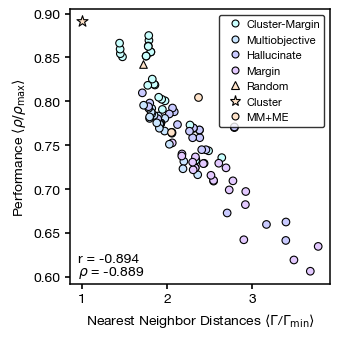

In [31]:
# Visualize correlation between coverage and performance.
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.1
fig, ax = plt.subplots(1,1,figsize=(3.5, 3.5))

# colors = []
# for iter, row in merged.iterrows():
#     # if row['Strategy'] == 'al':
#     #     colors.append("#C4DCFB")
#     # elif row['Strategy'] == 'sf' and row['Sampler'] == 'random':
#     #     colors.append("#B3B3B3")
#     # else:
#     #     colors.append("#FD8383")
        
#     if 'cluster_margin' in row['Batch']:
#         colors.append("#D3E7FF")
#     elif 'pareto' in row['Batch']:
#         colors.append("#ABD2FF")
#     elif 'hallucinate' in row['Batch']:
#         colors.append("#78B6FC")
#     elif 'topk' in row['Batch']:
#         colors.append("#4399FC")
#     elif row['Strategy'] == 'sf' and row['Sampler'] == 'random':
#         colors.append("#C2C2C2")
#     elif row['Strategy'] == 'sf' and row['Sampler'] == 'medoids':
#         colors.append("#FFCFAB")
#     else:
#         colors.append("#FD8989")

random_idx = -1
cluster_idx = -1
al_colors = []
for iter, row in merged.iterrows():
    if 'cluster_margin' in row['Batch']:
        al_colors.append("#C9FFFE")
    elif 'pareto' in row['Batch']:
        al_colors.append("#C9E5FF")
    elif 'hallucinate' in row['Batch']:
        al_colors.append("#C9CAFF")
    elif 'topk' in row['Batch']:
        al_colors.append("#E3C9FF")
    elif row['Strategy'] == 'sf' and row['Sampler'] == 'random':
        random_idx = iter
    elif row['Strategy'] == 'sf' and row['Sampler'] == 'medoids':
        cluster_idx = iter

# Plot AL algorithms.
ax.scatter(merged[merged['Strategy'] == 'al']['coverage-mean'], merged[merged['Strategy'] == 'al']['metric-mean'], s=30, color=al_colors, edgecolors='black', linewidth=0.8, zorder=5)

# Plot SF algorithms.
ax.scatter(
    merged[(merged['Strategy'] == 'sf') & ((merged['Sampler'] == 'maximin') | (merged['Sampler'] == 'max_entropy'))]['coverage-mean'], 
    merged[(merged['Strategy'] == 'sf') & ((merged['Sampler'] == 'maximin') | (merged['Sampler'] == 'max_entropy'))]['metric-mean'], 
    s=30, color='#FFE3C9', edgecolors='black', linewidth=0.8, zorder=10
)

# Plot random selection.
ax.scatter(
    merged.iloc[random_idx]['coverage-mean'],
    merged.iloc[random_idx]['metric-mean'],
    marker='^',
    s=30, color='#FFE3C9', edgecolors='black', linewidth=0.8, zorder=10,
)

# Plot cluster selection.
ax.scatter(
    merged.iloc[cluster_idx]['coverage-mean'],
    merged.iloc[cluster_idx]['metric-mean'],
    marker='*',
    s=70, color='#FFE3C9', edgecolors='black', linewidth=0.8, zorder=10,
)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='Cluster-Margin',
        markerfacecolor='#C9FFFE',
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='Multiobjective',
        markerfacecolor='#C9E5FF',
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='Hallucinate',
        markerfacecolor='#C9CAFF',
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='Margin',
        markerfacecolor='#E3C9FF',
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='^',
        color='none',
        label='Random',
        markerfacecolor='#FFE3C9',
        markeredgecolor='black',
        markersize=6,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='*',
        color='none',
        label='Cluster',
        markerfacecolor='#FFE3C9',
        markeredgecolor='black',
        markersize=8,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='MM+ME',
        markerfacecolor='#FFE3C9',
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),

]

ax.set_xlabel(r'Nearest Neighbor Distances $\langle\Gamma$/$\Gamma_{\text{min}}\rangle$')
# ax.set_xlim(xmin=0.18, xmax=0.9)
# ax.set_ylim(ymin=0.67, ymax=0.92)
ax.set_ylabel(r'Performance $\langle\rho/\rho_{\text{max}}\rangle$')
ax.tick_params(axis='both', left=True, bottom=True, width=1.2)

leg = ax.legend(handles=legend_elements, edgecolor='black', handletextpad=0.05, fontsize=8, frameon=True)

from scipy.stats import pearsonr, spearmanr
r = pearsonr(merged['coverage-mean'], merged['metric-mean']).statistic
rho = spearmanr(merged['coverage-mean'], merged['metric-mean']).statistic
ax.text(0.03, 0.08, f'r = {r:.3f}', ha='left', transform=ax.transAxes)
ax.text(0.03, 0.03, rf'$\rho$ = {rho:.3f}', ha='left', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(f'./figures/wcss_{SIZE}.pdf', dpi=500)
plt.show()